In [3]:
# =============================================================================
# 02_preprocessing.ipynb – Datenvorbereitung & Feature Engineering
# Projekt: MSIT Mock Interview – Loan Status Klassifikation
# Basis: Entscheidungen aus reports/eda_summary.md
# =============================================================================

# --- Standard Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Scikit-learn: Preprocessing ---
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    PowerTransformer      # Yeo-Johnson Transformation
)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# --- Ausgabepfade ---
Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../reports/figures").mkdir(parents=True, exist_ok=True)

# --- Darstellungskonfiguration ---
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Imports erfolgreich geladen.")

✅ Imports erfolgreich geladen.


In [4]:
# =============================================================================
# Zelle 2 – Rohdaten laden
# - df_raw:           Originaldatensatz – wird NIE verändert
# - df_raw_reference: Aufbereitete Rohdaten für spätere Vergleiche/Plots
# - df:               Arbeitskopie – wird durch Preprocessing verändert
# =============================================================================

# --- Originaldaten laden ---
df_raw = pd.read_csv("../data/raw/loans_modified.csv")

# --- Referenz-Datensatz für Visualisierungen ---
# Median-Imputation nur für Vergleichszwecke – kein Einfluss auf Preprocessing
df_raw_reference = df_raw.copy()
df_raw_reference["total_income"] = (
    df_raw_reference["applicant_income"].fillna(
        df_raw_reference["applicant_income"].median()) +
    df_raw_reference["coapplicant_income"].fillna(
        df_raw_reference["coapplicant_income"].median())
)

# --- Arbeitskopie ---
df = df_raw.copy()

print(f"df_raw Shape:           {df_raw.shape}")
print(f"df_raw_reference Shape: {df_raw_reference.shape}")
print(f"df Shape:               {df.shape}")
print(f"\ndf_raw_reference Spalten: {df_raw_reference.columns.tolist()}")
print(f"\nErste 3 Zeilen:")
df_raw.head(3)

df_raw Shape:           (563, 13)
df_raw_reference Shape: (563, 14)
df Shape:               (563, 13)

df_raw_reference Spalten: ['loan_id', 'gender', 'married', 'dependents', 'education', 'self_employed', 'applicant_income', 'coapplicant_income', 'loan_amount', 'loan_amount_term', 'credit_history', 'property_area', 'loan_status', 'total_income']

Erste 3 Zeilen:


,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,LP001003,Male,Yes,1,Graduate,No,4583.0000,1508.0000,128.0000,360.0000,1.0000,Rural,0.0000
1,LP001005,Male,Yes,0,Graduate,NaN,3000.0000,0.0000,66.0000,360.0000,1.0000,Urban,1.0000
2,LP001006,Male,Yes,0,Not Graduate,No,2583.0000,2358.0000,120.0000,360.0000,1.0000,Urban,1.0000


In [5]:
# =============================================================================
# Zelle 3 – Schritt 1: Kritische NaN-Zeilen entfernen
# Strategie aus EDA: loan_status und loan_id NaN → Zeilen entfernen
# =============================================================================

n_vor = len(df)

# --- loan_status NaN entfernen – Zielvariable nie imputieren ---
df = df.dropna(subset=["loan_status"])

# --- loan_id NaN entfernen – ID ohne Wert nicht verwendbar ---
df = df.dropna(subset=["loan_id"])

n_nach = len(df)

print(f"Zeilen vor:    {n_vor}")
print(f"Zeilen nach:   {n_nach}")
print(f"Entfernt:      {n_vor - n_nach}")
print(f"\nloan_status NaN verbleibend: {df['loan_status'].isnull().sum()}")
print(f"loan_id NaN verbleibend:     {df['loan_id'].isnull().sum()}")
print(f"\nKlassenverteilung loan_status:")
print(df["loan_status"].value_counts(dropna=False))

Zeilen vor:    563
Zeilen nach:   508
Entfernt:      55

loan_status NaN verbleibend: 0
loan_id NaN verbleibend:     0

Klassenverteilung loan_status:
loan_status
1.0000    363
0.0000    145
Name: count, dtype: int64


In [6]:
# =============================================================================
# Zelle 4 – Schritt 2: Feature Engineering
# WICHTIG: Vor Imputation – nur Features die keine Imputation benötigen
# total_income wird NACH Imputation in Zelle 5b berechnet
#
# Neue Features:
# - has_coapplicant:  1 wenn coapplicant_income > 0, sonst 0
# - is_standard_term: 1 wenn loan_amount_term == 360, sonst 0
# =============================================================================

# --- has_coapplicant ---
df["has_coapplicant"] = (df["coapplicant_income"] > 0).astype(int)

# --- is_standard_term ---
df["is_standard_term"] = (df["loan_amount_term"] == 360).astype(int)

print("✅ Feature Engineering abgeschlossen.")
print(f"\nNeue Features:")
print(f"  has_coapplicant:  {df['has_coapplicant'].value_counts().to_dict()}")
print(f"  is_standard_term: {df['is_standard_term'].value_counts().to_dict()}")
print(f"\nShape: {df.shape}")

✅ Feature Engineering abgeschlossen.

Neue Features:
  has_coapplicant:  {1: 271, 0: 237}
  is_standard_term: {1: 415, 0: 93}

Shape: (508, 15)


In [7]:
# =============================================================================
# Zelle 5 – Schritt 3: Imputation fehlender Werte
# Strategie aus EDA:
#   Numerisch  → Median (robust gegenüber Ausreißern)
#   Kategorisch → Modus
# =============================================================================

# --- Spalten definieren ---
num_cols_impute = ["applicant_income", "coapplicant_income",
                   "loan_amount", "loan_amount_term", "credit_history"]

cat_cols_impute = ["gender", "married", "dependents", "education",
                   "self_employed", "property_area"]

# --- Fehlende Werte vor Imputation ---
print("=== Fehlende Werte VOR Imputation ===")
missing_before = df[num_cols_impute + cat_cols_impute].isnull().sum()
print(missing_before[missing_before > 0].to_string())

# --- Numerische Imputation: Median ---
imputer_median = SimpleImputer(strategy="median")
df[num_cols_impute] = imputer_median.fit_transform(df[num_cols_impute])

# --- Kategorische Imputation: Modus ---
imputer_mode = SimpleImputer(strategy="most_frequent")
df[cat_cols_impute] = imputer_mode.fit_transform(df[cat_cols_impute])

# --- Fehlende Werte nach Imputation ---
print("\n=== Fehlende Werte NACH Imputation ===")
missing_after = df[num_cols_impute + cat_cols_impute].isnull().sum()
print(missing_after.to_string())

print(f"\n✅ Imputation abgeschlossen – NaN gesamt: {df.isnull().sum().sum()}")
print(f"Shape: {df.shape}")

=== Fehlende Werte VOR Imputation ===
applicant_income      24
coapplicant_income    33
loan_amount           28
loan_amount_term      25
credit_history        18
gender                22
married               17
dependents            30
education             20
self_employed         32
property_area         20

=== Fehlende Werte NACH Imputation ===
applicant_income      0
coapplicant_income    0
loan_amount           0
loan_amount_term      0
credit_history        0
gender                0
married               0
dependents            0
education             0
self_employed         0
property_area         0

✅ Imputation abgeschlossen – NaN gesamt: 0
Shape: (508, 15)


In [8]:
# =============================================================================
# Zelle 5b – total_income NACH Imputation berechnen
# Korrekte Reihenfolge: Imputation → Feature Engineering abhängiger Features
# =============================================================================

# --- total_income im Originalraum ---
df["total_income"] = df["applicant_income"] + df["coapplicant_income"]

print("✅ total_income berechnet.")
print(f"  NaN in total_income: {df['total_income'].isnull().sum()}")
print(f"  Min:  {df['total_income'].min():.2f}")
print(f"  Mean: {df['total_income'].mean():.2f}")
print(f"  Max:  {df['total_income'].max():.2f}")
print(f"  Skewness: {df['total_income'].skew():.4f}")
print(f"\nShape: {df.shape}")

✅ total_income berechnet.
  NaN in total_income: 0
  Min:  1442.00
  Mean: 7095.20
  Max:  81000.00
  Skewness: 5.7179

Shape: (508, 16)


In [9]:
# =============================================================================
# Zelle 6 – Schritt 4: Encoding kategorischer Features
# Strategie aus EDA:
#   Binär (2 Kategorien)  → Label Encoding
#   dependents            → Ordinales Encoding (3+ → 3)
#   property_area         → One-Hot Encoding (3 Kategorien)
# =============================================================================

# --- 6a: Label Encoding – binäre Features ---
binary_cols = ["gender", "married", "education", "self_employed"]

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# --- 6b: Ordinales Encoding – dependents ---
# 3+ wird zu 3 – natürliche Ordnung bleibt erhalten
dependents_map = {"0": 0, "1": 1, "2": 2, "3+": 3}
df["dependents"] = df["dependents"].map(dependents_map)

print(f"\ndependents: {dependents_map}")
print(f"dependents NaN nach Mapping: {df['dependents'].isnull().sum()}")

# --- 6c: One-Hot Encoding – property_area ---
ohe = OneHotEncoder(sparse_output=False, drop="first")  # drop first → Dummy-Variable-Falle vermeiden
property_encoded = ohe.fit_transform(df[["property_area"]])
property_cols    = ohe.get_feature_names_out(["property_area"])

df_property = pd.DataFrame(property_encoded,
                           columns=property_cols,
                           index=df.index)

# Original-Spalte entfernen & kodierte Spalten hinzufügen
df = df.drop(columns=["property_area"])
df = pd.concat([df, df_property], axis=1)

print(f"\nproperty_area One-Hot Spalten: {property_cols.tolist()}")
print(f"\n✅ Encoding abgeschlossen.")
print(f"Shape: {df.shape}")
print(f"\nDatentypen:\n{df.dtypes}")

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
married: {'No': np.int64(0), 'Yes': np.int64(1)}
education: {'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}
self_employed: {'No': np.int64(0), 'Yes': np.int64(1)}

dependents: {'0': 0, '1': 1, '2': 2, '3+': 3}
dependents NaN nach Mapping: 0

property_area One-Hot Spalten: ['property_area_Semiurban', 'property_area_Urban']

✅ Encoding abgeschlossen.
Shape: (508, 17)

Datentypen:
loan_id                        str
gender                       int64
married                      int64
dependents                   int64
education                    int64
self_employed                int64
applicant_income           float64
coapplicant_income         float64
loan_amount                float64
loan_amount_term           float64
credit_history             float64
loan_status                float64
has_coapplicant              int64
is_standard_term             int64
total_income               float64
property_area_Semiurban    float64

In [10]:
# =============================================================================
# Zelle 7 – Schritt 5: Yeo-Johnson Transformation
# Features: applicant_income, coapplicant_income, loan_amount, total_income
# Strategie aus EDA:
#   - Stark rechtsschief → Yeo-Johnson reduziert Schiefe
#   - Besser als Log: funktioniert auch mit Nullwerten (coapplicant_income)
#   - credit_history, loan_amount_term → keine Transformation
# =============================================================================

cols_to_transform = ["applicant_income", "coapplicant_income",
                     "loan_amount", "total_income"]

# --- Transformer initialisieren ---
pt = PowerTransformer(method="yeo-johnson", standardize=False)

# --- Transformation ---
df_transformed = df.copy()
df_transformed[cols_to_transform] = pt.fit_transform(df[cols_to_transform])

# --- Vergleich: Skewness vor vs. nach ---
print("=== Skewness: Vor vs. Nach Yeo-Johnson ===\n")
comparison = pd.DataFrame({
    "Skewness Vorher": df[cols_to_transform].skew().round(4),
    "Skewness Nachher": df_transformed[cols_to_transform].skew().round(4),
})
comparison["Verbesserung"] = (
    comparison["Skewness Vorher"].abs() - comparison["Skewness Nachher"].abs()
).round(4)
comparison["Effektiv?"] = comparison["Verbesserung"].apply(
    lambda x: "✅ Ja" if x > 0.5 else "⚠️ Moderat" if x > 0 else "❌ Nein"
)
print(comparison.to_string())

# --- Transformation übernehmen ---
df = df_transformed.copy()

print(f"\n✅ Yeo-Johnson Transformation abgeschlossen.")
print(f"Shape: {df.shape}")


=== Skewness: Vor vs. Nach Yeo-Johnson ===

                    Skewness Vorher  Skewness Nachher  Verbesserung Effektiv?
applicant_income             6.7810           -0.1251        6.6559      ✅ Ja
coapplicant_income           7.4803           -0.2619        7.2184      ✅ Ja
loan_amount                  2.5952            0.0257        2.5695      ✅ Ja
total_income                 5.7179           -0.0379        5.6800      ✅ Ja

✅ Yeo-Johnson Transformation abgeschlossen.
Shape: (508, 17)


In [11]:
# =============================================================================
# Zelle 8 – Schritt 6: Zielvariable & loan_id bereinigen
# - loan_status → int (0/1)
# - credit_history → int (0/1)
# - loan_id → entfernen (kein Prädiktor)
# =============================================================================

# --- loan_status zu int ---
df["loan_status"] = df["loan_status"].astype(int)

# --- credit_history zu int ---
df["credit_history"] = df["credit_history"].astype(int)

# --- loan_id entfernen ---
df = df.drop(columns=["loan_id"])

print("✅ Bereinigung abgeschlossen.")
print(f"Shape: {df.shape}")
print(f"\nDatentypen:\n{df.dtypes}")
print(f"\nloan_status Verteilung:\n{df['loan_status'].value_counts()}")
print(f"\nNaN gesamt: {df.isnull().sum().sum()}")

✅ Bereinigung abgeschlossen.
Shape: (508, 16)

Datentypen:
gender                       int64
married                      int64
dependents                   int64
education                    int64
self_employed                int64
applicant_income           float64
coapplicant_income         float64
loan_amount                float64
loan_amount_term           float64
credit_history               int64
loan_status                  int64
has_coapplicant              int64
is_standard_term             int64
total_income               float64
property_area_Semiurban    float64
property_area_Urban        float64
dtype: object

loan_status Verteilung:
loan_status
1    363
0    145
Name: count, dtype: int64

NaN gesamt: 0


In [12]:
# =============================================================================
# Zelle 9 – Train/Test Split & Processed Data speichern
# Strategie:
#   - 80/20 Split – Standard für kleine Datensätze
#   - Stratified – Klassenverteilung in beiden Sets erhalten
#   - random_state=42 – Reproduzierbarkeit
# =============================================================================

# --- Features & Zielvariable ---
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

print(f"Features (X): {X.shape}")
print(f"Target  (y):  {y.shape}")
print(f"\nFeature-Liste:\n{X.columns.tolist()}")

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # Klassenverteilung erhalten
)

print(f"\n=== Split Ergebnis ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nKlassenverteilung Train:")
print(y_train.value_counts(normalize=True).round(4))
print(f"\nKlassenverteilung Test:")
print(y_test.value_counts(normalize=True).round(4))

# --- Processed Data speichern ---
X_train.to_csv("../data/processed/X_train.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv",  index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv",   index=False)

# --- Vollständiger processed Datensatz ---
df.to_csv("../data/processed/loans_processed.csv", index=False)

print(f"\n✅ Gespeichert in data/processed/:")
print(f"   X_train.csv, X_test.csv, y_train.csv, y_test.csv")
print(f"   loans_processed.csv")

Features (X): (508, 15)
Target  (y):  (508,)

Feature-Liste:
['gender', 'married', 'dependents', 'education', 'self_employed', 'applicant_income', 'coapplicant_income', 'loan_amount', 'loan_amount_term', 'credit_history', 'has_coapplicant', 'is_standard_term', 'total_income', 'property_area_Semiurban', 'property_area_Urban']

=== Split Ergebnis ===
X_train: (406, 15)
X_test:  (102, 15)

Klassenverteilung Train:
loan_status
1   0.7143
0   0.2857
Name: proportion, dtype: float64

Klassenverteilung Test:
loan_status
1   0.7157
0   0.2843
Name: proportion, dtype: float64

✅ Gespeichert in data/processed/:
   X_train.csv, X_test.csv, y_train.csv, y_test.csv
   loans_processed.csv


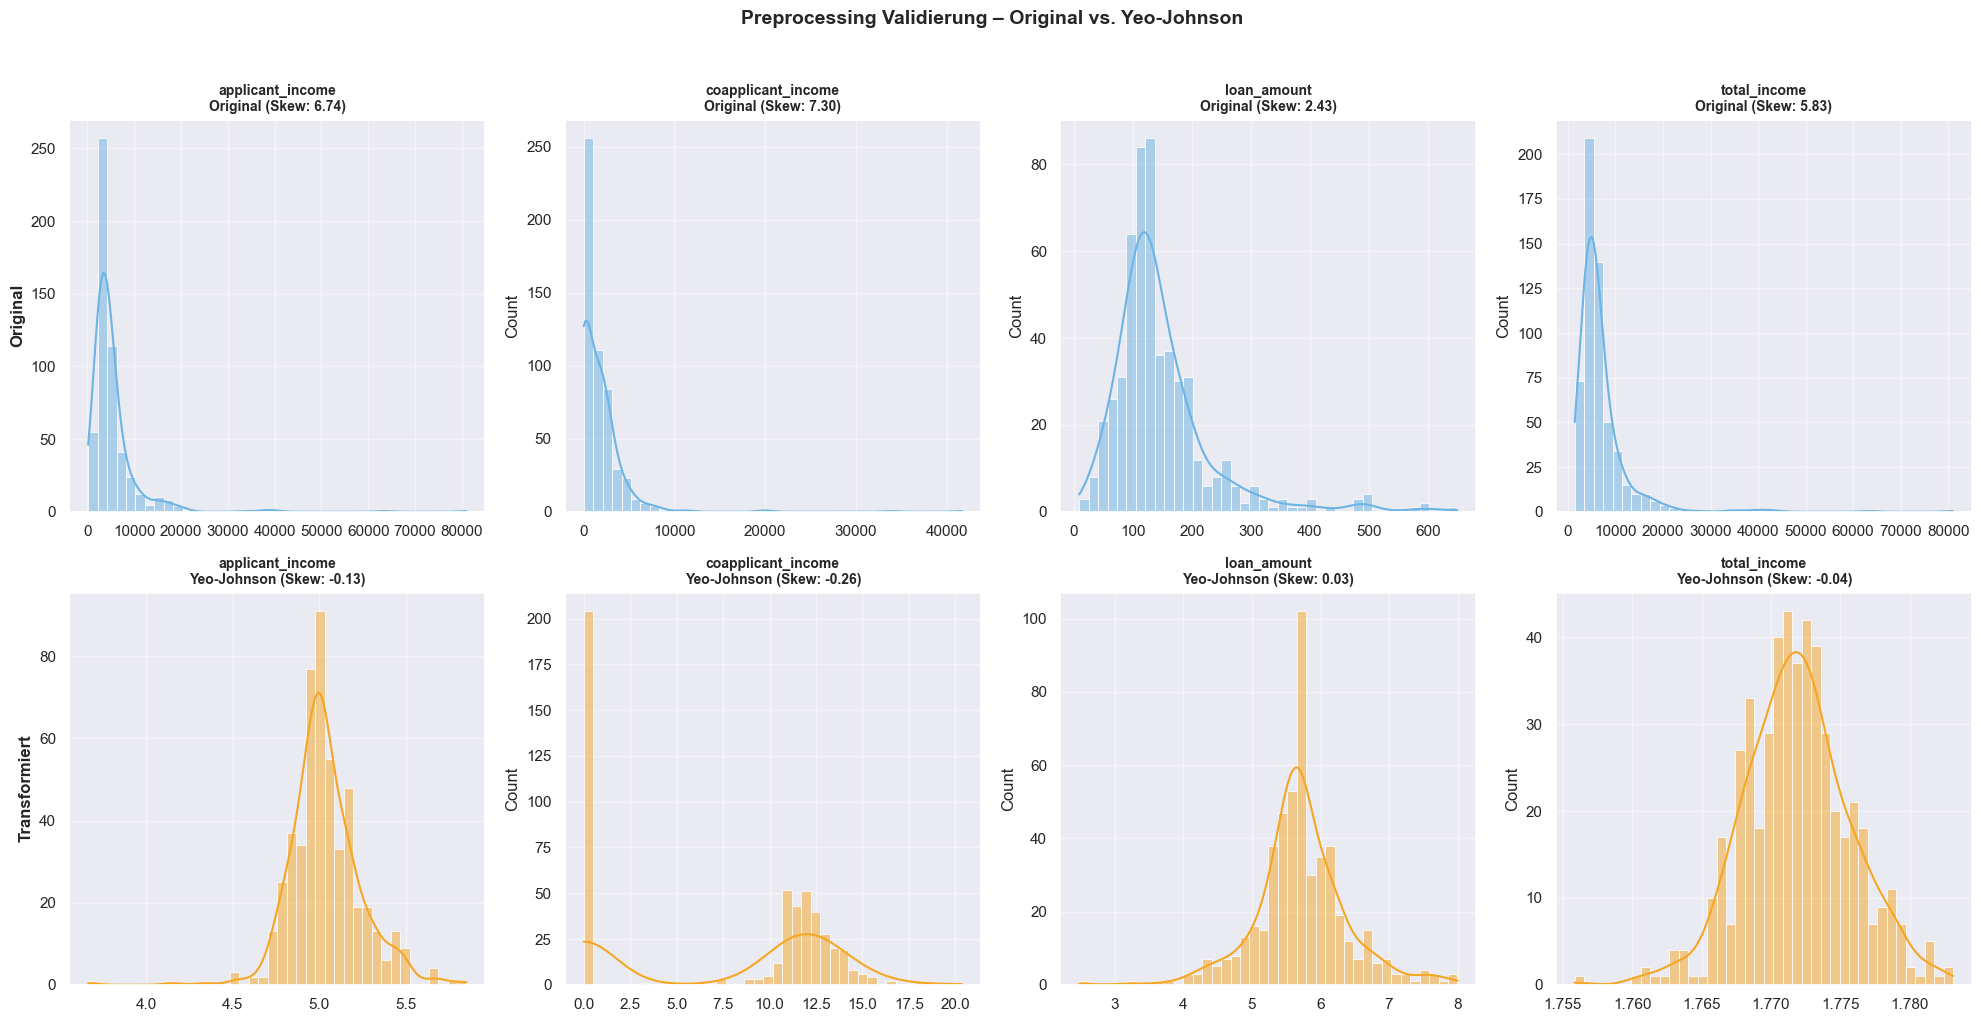

✅ Plot gespeichert: reports/figures/14_preprocessing_validation.png


In [14]:
# =============================================================================
# Zelle 10 – Preprocessing Validierung
# Ziel: Transformation visuell bestätigen – Vorher vs. Nachher
# =============================================================================

cols_plot = ["applicant_income", "coapplicant_income",
             "loan_amount", "total_income"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, col in enumerate(cols_plot):
    # --- Original (aus df_raw_reference) ---
    ax_orig = axes[0, i]
    raw_data = df_raw_reference[col].dropna()
    sns.histplot(raw_data, bins=40, kde=True,
                 ax=ax_orig, color="#6CB4E4")
    ax_orig.set_title(f"{col}\nOriginal (Skew: {raw_data.skew():.2f})",
                      fontsize=10, fontweight="bold")
    ax_orig.set_xlabel("")

    # --- Transformiert ---
    ax_trans = axes[1, i]
    trans_data = df[col]
    sns.histplot(trans_data, bins=40, kde=True,
                 ax=ax_trans, color="#F5A623")
    ax_trans.set_title(f"{col}\nYeo-Johnson (Skew: {trans_data.skew():.2f})",
                       fontsize=10, fontweight="bold")
    ax_trans.set_xlabel("")

axes[0, 0].set_ylabel("Original", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Transformiert", fontsize=12, fontweight="bold")

plt.suptitle("Preprocessing Validierung – Original vs. Yeo-Johnson",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/14_preprocessing_validation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot gespeichert: reports/figures/14_preprocessing_validation.png")

In [15]:
# =============================================================================
# Zelle 11 – Preprocessing Summary als Markdown-Datei generieren
# Speicherort: reports/preprocessing_summary.md
# =============================================================================

summary = """# Preprocessing Summary – Loan Status Klassifikation
**Projekt:** MSIT Mock Interview
**Notebook:** 02_preprocessing.ipynb
**Basis:** EDA Summary – reports/eda_summary.md

---

## 1. Ausgangslage

| Merkmal | Wert |
|---------|------|
| Zeilen original | 563 |
| Zeilen nach Bereinigung | 508 |
| Entfernte Zeilen | 55 (~9.8%) |
| Features original | 13 |
| Features nach Preprocessing | 15 |
| Zielvariable | loan_status (0/1) |

---

## 2. Entfernte Zeilen

| Grund | Anzahl |
|-------|--------|
| `loan_status` NaN – Zielvariable nie imputieren | 28 |
| `loan_id` NaN – ID ohne Wert nicht verwendbar | 27 |
| **Gesamt** | **55** |

---

## 3. Feature Engineering

| Feature | Formel | Begründung |
|---------|--------|-----------|
| `has_coapplicant` | 1 wenn coapplicant_income > 0 | Strukturproblem coapplicant_income – viele Nullwerte |
| `is_standard_term` | 1 wenn loan_amount_term == 360 | IQR=0 – kaum Varianz in loan_amount_term |
| `total_income` | applicant_income + coapplicant_income | Gesamteinkommen als Interaktionsterm |

### Verteilung neue Features
| Feature | Klasse 0 | Klasse 1 | Gesamt |
|---------|----------|----------|--------|
| `has_coapplicant` = 1 | 204 (40%) | 304 (60%) | 508 |
| `is_standard_term` = 1 | 440 (87%) | 68 (13%) | 508 |

⚠️ **Reihenfolge kritisch:**
- `has_coapplicant` und `is_standard_term` → vor Imputation (echte Nullwerte)
- `total_income` → nach Imputation (sonst NaN-Propagation)

---

## 4. Imputation

| Feature | Typ | Strategie | Begründung |
|---------|-----|-----------|-----------|
| `applicant_income` | Numerisch | Median | Robust gegenüber Ausreißern |
| `coapplicant_income` | Numerisch | Median | Robust gegenüber Ausreißern |
| `loan_amount` | Numerisch | Median | Robust gegenüber Ausreißern |
| `loan_amount_term` | Numerisch | Median | Robust gegenüber Ausreißern |
| `credit_history` | Binär | Modus | Binäres Feature |
| `gender` | Kategorisch | Modus | MCAR bestätigt |
| `married` | Kategorisch | Modus | MCAR bestätigt |
| `dependents` | Kategorisch | Modus | MCAR bestätigt |
| `education` | Kategorisch | Modus | MCAR bestätigt |
| `self_employed` | Kategorisch | Modus | MCAR bestätigt |
| `property_area` | Kategorisch | Modus | MCAR bestätigt |

**Basis:** MCAR in EDA bestätigt – Imputation statistisch vertretbar.

---

## 5. Encoding

| Feature | Methode | Mapping |
|---------|---------|---------|
| `gender` | Label Encoding | Female=0, Male=1 |
| `married` | Label Encoding | No=0, Yes=1 |
| `education` | Label Encoding | Graduate=0, Not Graduate=1 |
| `self_employed` | Label Encoding | No=0, Yes=1 |
| `dependents` | Ordinales Encoding | 0→0, 1→1, 2→2, 3+→3 |
| `property_area` | One-Hot Encoding (drop first) | Rural=Referenz, Semiurban, Urban |

**Dummy-Variable-Falle:** `drop="first"` → Rural als Referenzkategorie.

---

## 6. Yeo-Johnson Transformation

| Feature | Skewness Vorher | Skewness Nachher | Verbesserung |
|---------|----------------|-----------------|-------------|
| `coapplicant_income` | 7.48 | -0.26 | ✅ 7.22 |
| `total_income` | 5.72 | -0.04 | ✅ 5.68 |
| `applicant_income` | 6.78 | -0.13 | ✅ 6.65 |
| `loan_amount` | 2.60 | 0.03 | ✅ 2.57 |

**Warum Yeo-Johnson statt Log:**
- Log-Transformation funktioniert nicht bei Nullwerten (`coapplicant_income` = 0)
- Yeo-Johnson unterstützt negative Werte und Nullwerte
- Optimal durch Lambda-Schätzung – kein pauschaler Ansatz

⚠️ **`coapplicant_income` nach Transformation:**
Bimodale Struktur verbleibt – strukturelles Problem (mit/ohne Co-Applicant).
`has_coapplicant` Binary Feature fängt diese Information auf.

---

## 7. Entfernte Features

| Feature | Grund |
|---------|-------|
| `loan_id` | ID – kein Prädiktor |
| `loan_amount_term` | Ersetzt durch `is_standard_term` – MI=0.00 |

---

## 8. Train/Test Split

| Merkmal | Wert |
|---------|------|
| Split | 80/20 |
| Stratified | Ja |
| random_state | 42 |
| X_train | (406, 15) |
| X_test | (102, 15) |
| Klasse 1 Train | 71.43% |
| Klasse 1 Test | 71.57% |

---

## 9. Finale Feature-Liste

| # | Feature | Typ | Ursprung |
|---|---------|-----|---------|
| 1 | `gender` | int | Label Encoded |
| 2 | `married` | int | Label Encoded |
| 3 | `dependents` | int | Ordinal Encoded |
| 4 | `education` | int | Label Encoded |
| 5 | `self_employed` | int | Label Encoded |
| 6 | `applicant_income` | float | Yeo-Johnson |
| 7 | `coapplicant_income` | float | Yeo-Johnson |
| 8 | `loan_amount` | float | Yeo-Johnson |
| 9 | `credit_history` | int | Original (binär) |
| 10 | `has_coapplicant` | int | Feature Engineering |
| 11 | `is_standard_term` | int | Feature Engineering |
| 12 | `total_income` | float | Feature Engineering + Yeo-Johnson |
| 13 | `property_area_Semiurban` | float | One-Hot Encoded |
| 14 | `property_area_Urban` | float | One-Hot Encoded |

⚠️ **`loan_amount_term` entfernt** – ersetzt durch `is_standard_term`

---

## 10. Skalierung – Hinweis für Modeling

Skalierung wird **nicht** im Preprocessing durchgeführt –
sondern modellspezifisch in `03_modeling.ipynb`:

| Modell | Skalierung |
|--------|-----------|
| Logistic Regression | StandardScaler |
| SVM | StandardScaler |
| Random Forest | Keine |
| XGBoost | Keine |

---

## 11. Gespeicherte Dateien

| Datei | Inhalt |
|-------|--------|
| `data/processed/loans_processed.csv` | Vollständiger processed Datensatz |
| `data/processed/X_train.csv` | Training Features |
| `data/processed/X_test.csv` | Test Features |
| `data/processed/y_train.csv` | Training Labels |
| `data/processed/y_test.csv` | Test Labels |

---

## 12. Theoretische Grenzen

| Grenze | Detail |
|--------|--------|
| Modus-Imputation | Erhöht Dominanz der häufigsten Kategorie |
| Label Encoding | Impliziert Ordnung bei nominalen Features |
| Kleine Stichprobe | 508 Zeilen – Modell wird schnell overfitten |
| Yeo-Johnson coapplicant | Bimodale Struktur nicht vollständig auflösbar |
| One-Hot drop first | Rural als Referenz – Interpretation beachten |

---

*Erstellt: 02_preprocessing.ipynb – MSIT Mock Interview | 2026*
"""

# --- Datei speichern ---
with open("../reports/preprocessing_summary.md", "w", encoding="utf-8") as f:
    f.write(summary)

print("✅ Preprocessing Summary gespeichert: reports/preprocessing_summary.md")

✅ Preprocessing Summary gespeichert: reports/preprocessing_summary.md
